In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from glob import glob
import json


In [2]:
# Extract fUSI data, task events  and time stamps from each task

base_path = "/Users/clairenastaskin/data/sub-Forest001/2026-01-08/fusi"
task_list = [
    "task-audio_run-002", "task-audio_run-003", "task-audio_run-004", "task-audio_run-005",
    "task-audio_run-006", "task-audio_run-007", "task-audio_run-008", "task-audio_run-009"
]

fusi_data_list = []
t_r_list = []
task_events_list = []
frame_times_list = []

for i in range(len(task_list)):
    experiment_path = os.path.join(base_path, task_list[i])

    # Extract fUSI data and t_r
    fusi_path = glob(os.path.join(experiment_path, "*_pwd.nii.gz"))
    fusi_data = nib.load(fusi_path[0])
    fusi_data = fusi_data.get_fdata()
    fusi_data_list.append(fusi_data)

    t_r_path = os.path.join(experiment_path, "t_r.npy")
    t_r = np.load(t_r_path)
    t_r_list.append(t_r)


    # Extract time_stamps
    task_path = glob(os.path.join(experiment_path, '*.tsv'))[0]
    task_events = pd.read_csv(task_path, sep='\t')
    task_events_list.append(task_events)

    # Extract json info
    info_file_path = glob(os.path.join(experiment_path, "*pwd.json"))[0]
    # Read the json file
    with open(info_file_path, 'r') as f:
        info = json.load(f)

    frame_times = info['VolumeTiming']
    frame_times = np.array(frame_times)
    frame_times_list.append(frame_times)    

In [3]:
coords = (74,16,21) # Coordinate of the pixel of interest (with high z-score for example from freeview) from the non-realigned data 
radius = 3
timecourse_list = []
for i in range(len(task_list)):
    fusi_data = fusi_data_list[i]
    timecourse = np.mean(fusi_data[coords[0]-radius:coords[0]+radius,coords[1]-radius:coords[1]+radius,coords[2]-radius:coords[2]+radius,:],axis=(0,1,2))
    np.save(
        os.path.join(experiment_path, f"time_course_coord_{coords[0]}-{coords[1]}-{coords[2]}_radius{radius}.npy"),
        timecourse
    )
    timecourse_list.append(timecourse)

In [4]:
def boxcar_smooth(data, window_size):
    if window_size > 0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(
                data[:, :, :, start_index:end_index], axis=3
            )
    else:
        smoothed_data = data
    return smoothed_data


# Apply temporal smoothing with boxcar window
window_size = 3  # Number of time points to use for smoothing
for i in range(len(task_list)):
    timecourse = timecourse_list[i]
    timecourse = boxcar_smooth(timecourse[np.newaxis, np.newaxis, np.newaxis, :], window_size)[0,0,0,:]
    timecourse_list[i] = timecourse

In [5]:
# Detrend signal
from nilearn.signal import clean

for i in range(len(task_list)):
    timecourse = timecourse_list[i]
    t_r = t_r_list[i]
    # Reshape timecourse to 2D (nilearn expects shape: [n_timepoints, n_features])
    timecourse_2d = timecourse[:, np.newaxis]  # Shape: (237, 1)
    detrended_timecourse = clean(
        timecourse_2d,
        confounds=None,
        detrend=None,
        standardize=None,       
        low_pass=None,
        high_pass=0.01,
        t_r=t_r,
        ensure_finite=True,      # avoids NaN propagation
    )
    # Flatten back to 1D if needed
    detrended_timecourse = detrended_timecourse.flatten()
    timecourse_list[i] = detrended_timecourse

In [6]:
task_list_type = task_events.trial_type.unique()
print(task_list_type)


['Speech' 'Audio no speech']


In [7]:
print(frame_times_list[6].shape)

(240,)


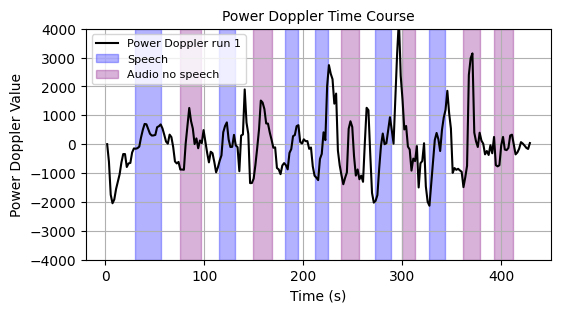

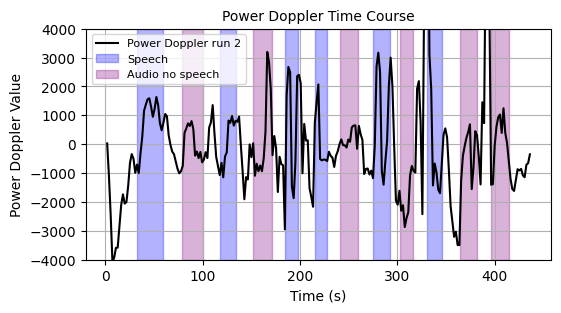

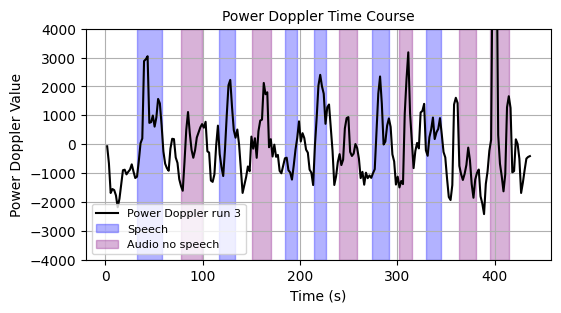

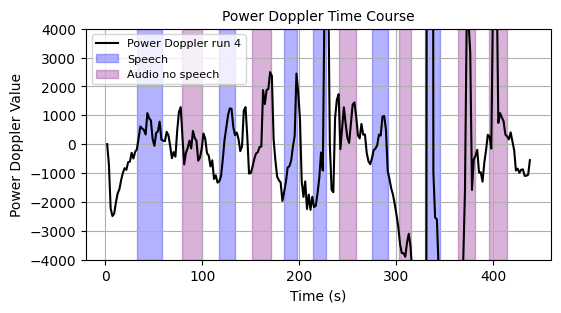

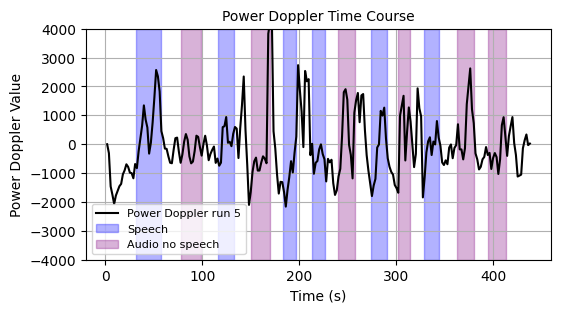

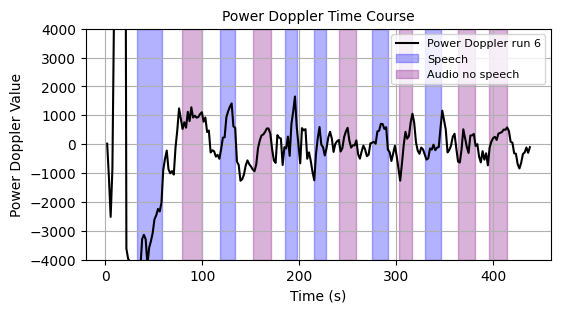

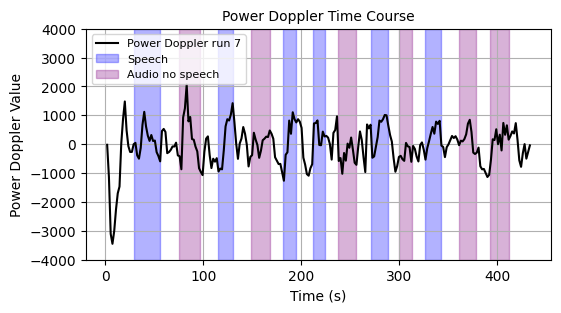

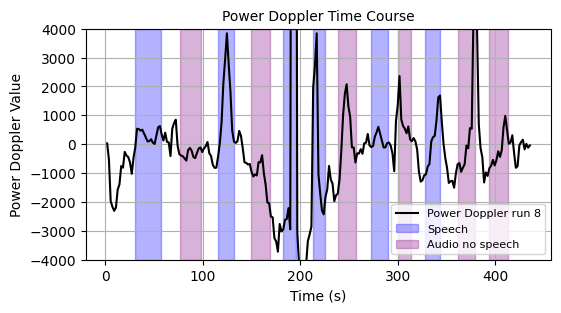

In [12]:
# Smooth the Power Doppler signal using a boxcar of width 2

for i in range(len(task_list)):
    signal = timecourse_list[i]; 

    plt.figure(figsize=(6, 3))
    plt.plot(
        frame_times_list[i],
        signal,
        color="black",
        label=f"Power Doppler run {i+1}"
    )

    task_colors = ['blue', 'purple', 'gray', 'lightgreen', 'red', 'orange', 'yellow', 'pink']

    # Add colored rectangles for stimulus periods
    task_events = task_events_list[i]
    for task_index in range(len(task_list_type)):
        task = task_list_type[task_index]
        task_events_timing = pd.DataFrame()
        task_events_timing["Event"] = ["start", "stop"] * len(
            task_events[task_events["trial_type"] == task]
        )
        task_events_timing["Timestamp"] = [
            onset
            for onset, duration in zip(
                task_events[task_events["trial_type"] == task]["onset"],
                task_events[task_events["trial_type"] == task]["duration"],
            )
            for _ in range(2)
        ]
        # No need to .values for pandas Series, just use .to_numpy() or direct array ops
        durations = task_events[task_events["trial_type"] == task]["duration"].to_numpy()
        task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += durations.repeat(1)
        task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
        start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
        stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
        # Use .iloc for pandas Series, not numpy arrays
        for i, (start, stop) in enumerate(zip(start_times, stop_times)):
            plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if i == 0 else "")

    plt.xlabel("Time (s)", fontsize=10)
    plt.ylabel("Power Doppler Value", fontsize=10)
    plt.title("Power Doppler Time Course", fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylim(-4000, 4000)
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()
